# Introduction to Pandas
further reading:
https://pandas.pydata.org/docs/user_guide/10min.html


In [1]:
#start with importing necessary libraries
import pandas as pd
import numpy as np


## Basic data structures in pandas

Pandas provides two types of classes for handling data:

- **Series**: a one-dimensional labeled array holding data of any single type such as integers, strings, Python objects etc.
- **DataFrame**: a two-dimensional data structure that holds data of multiple types in a table with rows and columns. Each column holds a single data type.



In [2]:
# create Pandas Series of numbers by passing list:
s0 = pd.Series([1, 2, 4, 5, 7])

# show series
print(s0)

0    1
1    2
2    4
3    5
4    7
dtype: int64


optional: open it in Data Wrangler (VSCode Extension):

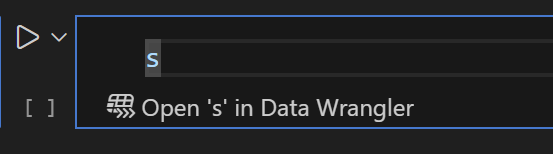

In [3]:
# create Pandas series of numbers by passing range:
s1 = pd.Series(range(3,8))

# show series
print(s1)

0    3
1    4
2    5
3    6
4    7
dtype: int64


In [4]:
# changing elements in series:
s1[3] = 0
print(s1)

#also works with lists
s1[[1, 2]] = [7, 8]
print(s1)


0    3
1    4
2    5
3    0
4    7
dtype: int64
0    3
1    7
2    8
3    0
4    7
dtype: int64


### 📝 Tasks for you:

In [10]:
# create a Pandas series with the first 10 fibonacci numbers (starting with 0, 1, 1, ...)
fib = pd.Series([0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55])
print(fib)
# replace every second number with its square number

for i, n in enumerate(fib):
    if (i+1) % 2 == 0:
        fib[i] = n * n

print(fib)
# replace every number which is divisible by 3 with 0.

for i, n in enumerate(fib):
    if n % 3 == 0:
        fib[i] = 0

print(fib)

# show the result

0      0
1      1
2      1
3      2
4      3
5      5
6      8
7     13
8     21
9     34
10    55
dtype: int64
0        0
1        1
2        1
3        4
4        3
5       25
6        8
7      169
8       21
9     1156
10      55
dtype: int64
0        0
1        1
2        1
3        4
4        0
5       25
6        8
7      169
8        0
9     1156
10      55
dtype: int64


In [11]:
# create Pandas Dataframe:
df = pd.DataFrame(
    {
        "A": [1.1, 2.2, np.nan, 4.4],
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(range(4), index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "rest", np.nan], ["test", "train", "rest"]),
        "F": ["foo", "bar", "func", "var"]
    }
)
df

,A,B,C,D,E,F
0,1.1,2013-01-02,0.0,3,test,foo
1,2.2,2013-01-02,1.0,3,train,bar
2,NaN,2013-01-02,2.0,3,rest,func
3,4.4,2013-01-02,3.0,3,NaN,var


### Selecting and Viewing Data Subsets

In [12]:
# subsets - columns
print(df["A"])
print(df.C)
print(df[["B","E"]])

0    1.1
1    2.2
2    NaN
3    4.4
Name: A, dtype: float64
0    0.0
1    1.0
2    2.0
3    3.0
Name: C, dtype: float32
           B      E
0 2013-01-02   test
1 2013-01-02  train
2 2013-01-02   rest
3 2013-01-02    NaN


In [21]:
#we can select rows in which a certain column has values that meet a certain criterium
print("C greater than 2:\n", df[df['C'] < 2.0], '\n')
print("A not equal 2.2:\n", df[df['A'] != 2.2], '\n')
print("A not equal 2.2 and C greater than 0:\n", df[(df['A'] != 2.2) & (df.C > 0)], '\n')

print("E starts with 't':\n", df[df['E'].str.match('t')], '\n')
print("E contains 't':\n", df[df['E'].str.contains('t')])


C greater than 2:
      A          B    C  D      E    F
0  1.1 2013-01-02  0.0  3   test  foo
1  2.2 2013-01-02  1.0  3  train  bar 

A not equal 2.2:
      A          B    C  D     E     F
0  1.1 2013-01-02  0.0  3  test   foo
2  NaN 2013-01-02  2.0  3  rest  func
3  4.4 2013-01-02  3.0  3   NaN   var 

A not equal 2.2 and C greater than 0:
      A          B    C  D     E     F
2  NaN 2013-01-02  2.0  3  rest  func
3  4.4 2013-01-02  3.0  3   NaN   var 

E starts with 't':
      A          B    C  D      E    F
0  1.1 2013-01-02  0.0  3   test  foo
1  2.2 2013-01-02  1.0  3  train  bar 

E contains 't':
      A          B    C  D      E     F
0  1.1 2013-01-02  0.0  3   test   foo
1  2.2 2013-01-02  1.0  3  train   bar
2  NaN 2013-01-02  2.0  3   rest  func


In [17]:
# show datatypes of columns:
df.dtypes

A           float64
B    datetime64[us]
C           float32
D             int32
E          category
F               str
dtype: object

In [18]:
#data size
print("Rows:", df.shape[0], " Columns:", df.shape[1])

#statistic output:
df.describe()

Rows: 4  Columns: 6


,A,B,C,D
count,3.000000,4,4.000000,4.0
mean,2.566667,2013-01-02 00:00:00,1.500000,3.0
min,1.100000,2013-01-02 00:00:00,0.000000,3.0
25%,1.650000,2013-01-02 00:00:00,0.750000,3.0
50%,2.200000,2013-01-02 00:00:00,1.500000,3.0
75%,3.300000,2013-01-02 00:00:00,2.250000,3.0
max,4.400000,2013-01-02 00:00:00,3.000000,3.0
std,1.680278,NaN,1.290994,0.0


Where are E and F columns?
-> when there are numerical columns, text columns will be ignored

### 📝 Tasks for you:

replace right sides of = with actual values

In [42]:
#use subsets to show statistics of text columns:
df[["E", "F"]].describe()

,E,F
count,3,4
unique,3,4
top,test,foo
freq,1,1


In [43]:
#how many rows does our dataset have?
dataset_rows = df.shape[0]
#how many values are there in column A?
dataset_values_A = df["A"].count()
#what is the lowest value in A?
lowest_A = np.min(df["A"])
#what is the highest value in C?
highest_C = np.max(df["C"])
#which date range [from, to] (without time) does the dataset cover?
dataset_daterange = []



print("Dataset Rows: " + str(dataset_rows))
print("Dataset Values: " + str(dataset_values_A))
print("Lowest A: " + str(lowest_A))
print("Highest C: " + str(highest_C))

Dataset Rows: 4
Dataset Values: 3
Lowest A: 1.1
Highest C: 3.0


### Adding Rows

In [20]:
# adding row values, calculations with row values
df["A"] + df["C"] * 2

0     1.1
1     4.2
2     NaN
3    10.4
dtype: float64

### 📝 Tasks for you:

In [44]:
# add a new column "R" to the dataframe df which holds the negative values of (A + C)

df["R"] = -1 * (df["A"] + df["C"])

In [46]:
df.R

0   -1.1
1   -3.2
2    NaN
3   -7.4
Name: R, dtype: float64

In [47]:
# Change of single value in cell

# ⚠️ Doesn't work like expected - read the info provided in the output:
df["A"][3] = 99
print(df)

     A          B    C  D      E     F    R
0  1.1 2013-01-02  0.0  3   test   foo -1.1
1  2.2 2013-01-02  1.0  3  train   bar -3.2
2  NaN 2013-01-02  2.0  3   rest  func  NaN
3  4.4 2013-01-02  3.0  3    NaN   var -7.4


/tmp/ipykernel_18848/1287700574.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df["A"][3] = 99


In [48]:
# Change of single value in cell - correct version:
df.loc[3, "A"] = 99
print(df)
print('')

# Change of value range with index - note the added 'i'!
df.iloc[1:3, 2:6] = np.nan
print(df)

      A          B    C  D      E     F    R
0   1.1 2013-01-02  0.0  3   test   foo -1.1
1   2.2 2013-01-02  1.0  3  train   bar -3.2
2   NaN 2013-01-02  2.0  3   rest  func  NaN
3  99.0 2013-01-02  3.0  3    NaN   var -7.4

      A          B    C    D     E    F    R
0   1.1 2013-01-02  0.0  3.0  test  foo -1.1
1   2.2 2013-01-02  NaN  NaN   NaN  NaN -3.2
2   NaN 2013-01-02  NaN  NaN   NaN  NaN  NaN
3  99.0 2013-01-02  3.0  3.0   NaN  var -7.4


In [49]:
# delete columns
df.drop("A")
# why error?

KeyError: "['A'] not found in axis"

In [53]:
#default axis = 0 -> rows, but there's no row 'A'. To delete column, use axis 1:
df.drop("A", axis=1)

,B,C,D,E,F,R
0,2013-01-02,0.0,3.0,test,foo,-1.1
1,2013-01-02,NaN,NaN,NaN,NaN,-3.2
2,2013-01-02,NaN,NaN,NaN,NaN,NaN
3,2013-01-02,3.0,3.0,NaN,var,-7.4


In [55]:
#to drop an entire row, use id of index:
df.drop(2)
# row 2 is gone...

,A,B,C,D,E,F,R
0,1.1,2013-01-02,0.0,3.0,test,foo,-1.1
1,2.2,2013-01-02,NaN,NaN,NaN,NaN,-3.2
3,99.0,2013-01-02,3.0,3.0,NaN,var,-7.4


In [56]:
# ⚠️ did something change?
df 
# row 2 is here again?

,A,B,C,D,E,F,R
0,1.1,2013-01-02,0.0,3.0,test,foo,-1.1
1,2.2,2013-01-02,NaN,NaN,NaN,NaN,-3.2
2,NaN,2013-01-02,NaN,NaN,NaN,NaN,NaN
3,99.0,2013-01-02,3.0,3.0,NaN,var,-7.4


In [57]:
# drop doesn't act on the data itself, it provides a copy without the dropped element. To act on the data itself, we have to explicitly say so.
# correct:
df.drop("A", axis=1, inplace=True)
print(df)

           B    C    D     E    F    R
0 2013-01-02  0.0  3.0  test  foo -1.1
1 2013-01-02  NaN  NaN   NaN  NaN -3.2
2 2013-01-02  NaN  NaN   NaN  NaN  NaN
3 2013-01-02  3.0  3.0   NaN  var -7.4


In [58]:
#or we simply could reassign the copy (without the dropped row) to the original:
df = df.drop("B", axis=1)
print(df)
# why error?

     C    D     E    F    R
0  0.0  3.0  test  foo -1.1
1  NaN  NaN   NaN  NaN -3.2
2  NaN  NaN   NaN  NaN  NaN
3  3.0  3.0   NaN  var -7.4


In [59]:
# ⚠️don't do both!
df_c = df.drop("C", axis=1, inplace=True)
print(df_c)
# everything is gone! drop with inplace=True doesn't return anything, so it's assigning nothing to df_c.

None


### Tidy Data
Tidy data is a data structure where:

- One **column** for each _variable_
- One **row** for each _observation_
- One **cell** for each _value_

#### Long format: 
Each row represents a single observation, and variables are stored in separate columns (for example, one row per gas station and fuel type).

Typically used for raw data, data analysis, coding tools, libraries

In [62]:
import pandas as pd

fuel_prices = pd.DataFrame({
    "GasStation": [
        "OMV", "OMV",
        "Shell", "Shell",
        "BP", "BP",
        "OMV", "OMV"
    ],
    "Address": [
        "Main St 1", "Main St 1",
        "High St 5", "High St 5",
        "Park Ave 10", "Park Ave 10",
        "Main St 1", "Main St 1"
    ],
    "Date": [
        "2022-08-13", "2022-08-13",
        "2022-08-13", "2022-08-13",
        "2022-08-13", "2022-08-13",
        "2022-08-14", "2022-08-14"
    ],
    "FuelType": [
        "Diesel", "Super95",
        "Diesel", "Super95",
        "Diesel", "Super95",
        "Diesel", "Super95"
    ],
    "Price": [
        1.75, 1.78,
        1.73, 1.77,
        1.80, 1.84,
        1.72, 1.76
    ]
})

fuel_prices

,GasStation,Address,Date,FuelType,Price
0,OMV,Main St 1,2022-08-13,Diesel,1.75
1,OMV,Main St 1,2022-08-13,Super95,1.78
2,Shell,High St 5,2022-08-13,Diesel,1.73
3,Shell,High St 5,2022-08-13,Super95,1.77
4,BP,Park Ave 10,2022-08-13,Diesel,1.80
5,BP,Park Ave 10,2022-08-13,Super95,1.84
6,OMV,Main St 1,2022-08-14,Diesel,1.72
7,OMV,Main St 1,2022-08-14,Super95,1.76


#### Wide format:
Values from one variable are spread across multiple columns, creating a matrix-like structure (for example, separate Super95 and Diesel columns for each gas station).

Typically used for better human readability, presentation, reporting

In [63]:
fuel_prices_wide = pd.DataFrame({
    "GasStation": ["OMV", "Shell", "BP", "OMV"],
    "Address": ["Main St 1", "High St 5", "Park Ave 10", "Main St 1"],
    "Date": ["2022-08-13", "2022-08-13", "2022-08-13", "2022-08-14"],
    "Diesel": [1.75, 1.73, 1.80, 1.72],
    "Super95": [1.78, 1.77, 1.84, 1.76]
})

fuel_prices_wide

,GasStation,Address,Date,Diesel,Super95
0,OMV,Main St 1,2022-08-13,1.75,1.78
1,Shell,High St 5,2022-08-13,1.73,1.77
2,BP,Park Ave 10,2022-08-13,1.80,1.84
3,OMV,Main St 1,2022-08-14,1.72,1.76


#### Pivot from Long to Wide format

In [64]:
wide_df = fuel_prices.pivot_table(
    index=["GasStation", "Address", "Date"],
    columns="FuelType",
    values="Price"
)

wide_df

FuelType                           Diesel  Super95
GasStation Address     Date                       
BP         Park Ave 10 2022-08-13    1.80     1.84
OMV        Main St 1   2022-08-13    1.75     1.78
                       2022-08-14    1.72     1.76
Shell      High St 5   2022-08-13    1.73     1.77

In [65]:
wide_df = wide_df.reset_index()
wide_df.columns.name = None

wide_df

,GasStation,Address,Date,Diesel,Super95
0,BP,Park Ave 10,2022-08-13,1.80,1.84
1,OMV,Main St 1,2022-08-13,1.75,1.78
2,OMV,Main St 1,2022-08-14,1.72,1.76
3,Shell,High St 5,2022-08-13,1.73,1.77


In Tidy Data, the variable is explicitly stored in the column:
- GasStation -> Gas Stations
- Adress -> Addresses
- FuelType -> Fuel Types
- Price -> Prices

while in the wide format, you have 2 price coloumns: 

Diesel(_price) and Super95(_price) -> the fuel Type (variable) is encoded in the column header and doesn't have it's own column.
